In [2]:
import pandas as pd
import io
from ipywidgets import FileUpload
from IPython.display import display

# Create and display an upload button widget
uploader = FileUpload(accept='.csv', multiple=False)
print("Click the button below to browse and select 'Scores.csv' from your PC:")
display(uploader)

Click the button below to browse and select 'Scores.csv' from your PC:


FileUpload(value=(), accept='.csv', description='Upload')

In [3]:
# Extract the uploaded file data into pandas
if uploader.value:
    # Get the uploaded file content
    uploaded_file = list(uploader.value)[0]
    file_content = uploaded_file['content']
    
    # Read the data using the semicolon separator
    df = pd.read_csv(io.BytesIO(file_content), sep=';')
    
    print("--- Success! Data Loaded Smoothly ---")
    print("\n--- First 5 Rows of the Dataset ---")
    print(df.head())
else:
    print("Please click the upload button in the previous cell first!")

--- Success! Data Loaded Smoothly ---

--- First 5 Rows of the Dataset ---
   game_id  passing_quote winner
0       11           72.0     No
1       11           91.0    Yes
2       12           82.0    Yes
3       12           86.0     No
4       13           82.0    Yes


In [4]:
import numpy as np

print("--- Total Records in Dataset ---")
print(f"Total rows: {len(df)}")

print("\n--- Missing Data Check ---")
print(df.isnull().sum())

print("\n--- Statistical Summary by Performance Outcome ---")
summary = df.groupby('winner')['passing_quote'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(summary)

--- Total Records in Dataset ---
Total rows: 306

--- Missing Data Check ---
game_id          0
passing_quote    2
winner           2
dtype: int64

--- Statistical Summary by Performance Outcome ---
        count       mean  median       std   min   max
winner                                                
No        190  78.842105    79.0  6.074173  59.0  90.0
Yes       114  81.078947    83.0  8.064063  53.0  92.0


C:\Users\User\AppData\Local\Temp\ipykernel_23000\3782350617.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='winner', y='passing_quote', data=df, palette='Set2')


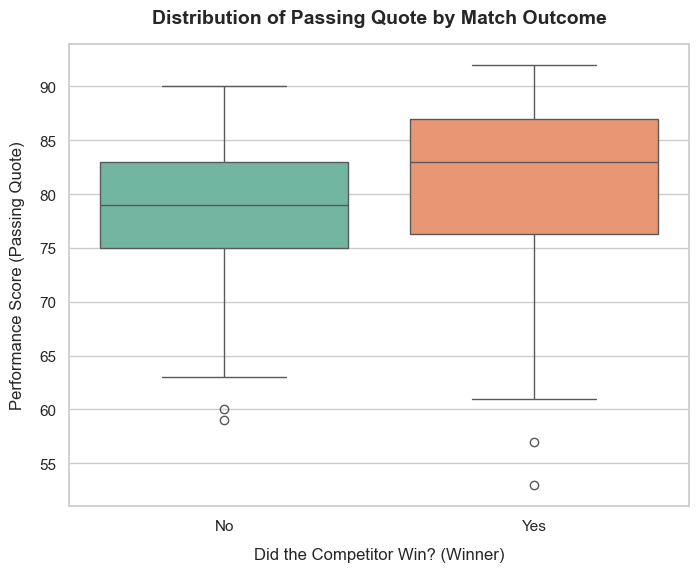

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean professional style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(x='winner', y='passing_quote', data=df, palette='Set2')

# Add explicit titles and labels for the German admissions committee
plt.title('Distribution of Passing Quote by Match Outcome', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Did the Competitor Win? (Winner)', fontsize=12, labelpad=10)
plt.ylabel('Performance Score (Passing Quote)', fontsize=12, labelpad=10)

# Display the plot
plt.show()

In [6]:
from scipy import stats

# Separate the two groups
winners = df[df['winner'] == 'Yes']['passing_quote']
losers = df[df['winner'] == 'No']['passing_quote']

# Perform Independent Two-Sample T-Test (Welch's T-test which accounts for unequal variances)
t_stat, p_val = stats.ttest_ind(winners, losers, equal_var=False)

print("--- Hypothesis Test Results ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# Interpret the results
alpha = 0.05
if p_val < alpha:
    print("\nConclusion: Reject the Null Hypothesis (H0). The difference is statistically significant.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis (H0). The difference is not statistically significant.")

--- Hypothesis Test Results ---
T-statistic: 2.5581
P-value: 0.0113

Conclusion: Reject the Null Hypothesis (H0). The difference is statistically significant.
